# Projet TP - Reconnaissance de panneaux (version fonctionnelle)

Ce notebook est conçu pour **s'exécuter de bout en bout**.

Il suit les 4 parties demandées :
1. Présentation du jeu de données
2. Méthodes classiques de reconnaissance
3. Méthode supervisée conçue et entraînée
4. Modèle pré-entraîné (transfer learning)

En cas d'absence de dataset GTSRB structuré, le notebook bascule en mode fallback avec les images locales et des pseudo-labels (démo fonctionnelle).

In [29]:
# Installation optionnelle
INSTALL_DEPS = False
if INSTALL_DEPS:
    import sys, subprocess
    pkgs = [
        'numpy', 'pandas', 'matplotlib', 'seaborn', 'opencv-python',
        'scikit-learn', 'scikit-image', 'tensorflow'
    ]
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-U'] + pkgs)
    print('Dependances installees.')
else:
    print('Installation ignoree (INSTALL_DEPS=False).')

Installation ignoree (INSTALL_DEPS=False).


In [30]:
import os
import random
import time
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from sklearn.svm import LinearSVC

from skimage.feature import hog

import tensorflow as tf
from tensorflow import keras

sns.set_theme(style='whitegrid')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

SEED = 42
set_seed(SEED)
print('TensorFlow:', tf.__version__)
print('Seed fixee:', SEED)

TensorFlow: 2.21.0
Seed fixee: 42


In [31]:
# Configuration chemins
PROJECT_ROOT = Path('..').resolve()
LOCAL_FLAT_DIR = PROJECT_ROOT / 'im' / 'panneaux'
LOCAL_GTSRB_DIR = PROJECT_ROOT / 'im' / 'gtsrb'

IMG_SIZE = (64, 64)
BATCH_SIZE = 32
EPOCHS_CNN = 8
EPOCHS_TL_FREEZE = 4
EPOCHS_TL_FINETUNE = 3
FAST_MODE = True
if FAST_MODE:
    EPOCHS_CNN = 4
    EPOCHS_TL_FREEZE = 2
    EPOCHS_TL_FINETUNE = 2

print('PROJECT_ROOT =', PROJECT_ROOT)
print('LOCAL_FLAT_DIR existe =', LOCAL_FLAT_DIR.exists())
print('LOCAL_GTSRB_DIR existe =', LOCAL_GTSRB_DIR.exists())

PROJECT_ROOT = C:\Users\madaggag\Documents\Python\Project\Cours\Traitement_Image
LOCAL_FLAT_DIR existe = True
LOCAL_GTSRB_DIR existe = True


In [32]:
import zipfile
from urllib.request import urlretrieve

DOWNLOAD_GTSRB = False  # Passe a True pour telecharger automatiquement
GTSRB_DOWNLOAD_DIR = LOCAL_GTSRB_DIR
GTSRB_DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)

GTSRB_URLS = {
    'train_zip': 'https://benchmark.ini.rub.de/Dataset/GTSRB_Final_Training_Images.zip',
    'test_zip': 'https://benchmark.ini.rub.de/Dataset/GTSRB_Final_Test_Images.zip',
    'test_gt': 'https://benchmark.ini.rub.de/Dataset/GTSRB_Final_Test_GT.zip',
}

def _download_file(url, out_path: Path):
    out_path.parent.mkdir(parents=True, exist_ok=True)
    if out_path.exists():
        print('Deja present:', out_path.name)
        return out_path
    print('Telechargement:', url)
    urlretrieve(url, str(out_path))
    print('OK:', out_path.name)
    return out_path

def _unzip_file(zip_path: Path, dest_dir: Path):
    marker = dest_dir / f'.unzipped_{zip_path.stem}'
    if marker.exists():
        print('Deja dezippe:', zip_path.name)
        return
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(dest_dir)
    marker.touch()
    print('Dezip OK:', zip_path.name)

if DOWNLOAD_GTSRB:
    try:
        train_zip = _download_file(GTSRB_URLS['train_zip'], GTSRB_DOWNLOAD_DIR / 'GTSRB_Final_Training_Images.zip')
        test_zip = _download_file(GTSRB_URLS['test_zip'], GTSRB_DOWNLOAD_DIR / 'GTSRB_Final_Test_Images.zip')
        test_gt_zip = _download_file(GTSRB_URLS['test_gt'], GTSRB_DOWNLOAD_DIR / 'GTSRB_Final_Test_GT.zip')

        _unzip_file(train_zip, GTSRB_DOWNLOAD_DIR)
        _unzip_file(test_zip, GTSRB_DOWNLOAD_DIR)
        _unzip_file(test_gt_zip, GTSRB_DOWNLOAD_DIR)
        print('Telechargement GTSRB termine.')
    except Exception as e:
        print('Echec telechargement automatique:', e)
        print('Continue avec les donnees locales deja presentes.')
else:
    print('Telechargement GTSRB desactive (DOWNLOAD_GTSRB=False).')

Telechargement GTSRB desactive (DOWNLOAD_GTSRB=False).


## Option TensorFlow - Telechargement GTSRB (inspire de ton lien)

Cette cellule est optionnelle. Elle telecharge et decompresse GTSRB en local pour alimenter directement la Partie 1.
- Si `DOWNLOAD_GTSRB = False`: aucun telechargement.
- Si `DOWNLOAD_GTSRB = True`: tentative de recuperation depuis les URLs publiques GTSRB.

## Partie 1 - Présentation du jeu de données

Objectif : charger les données, compter images/classes, visualiser distribution et exemples.

In [33]:
IMAGE_EXTS = {'.png', '.jpg', '.jpeg', '.ppm', '.bmp'}

def list_images(folder: Path):
    if not folder.exists():
        return []
    return [p for p in folder.rglob('*') if p.suffix.lower() in IMAGE_EXTS]

def load_gtsrb_like(root: Path):
    train_dir = root / 'Train'
    if not train_dir.exists():
        return None
    rows = []
    for class_dir in sorted([d for d in train_dir.iterdir() if d.is_dir()], key=lambda x: x.name):
        for p in list_images(class_dir):
            rows.append({'path': str(p), 'label_raw': class_dir.name, 'source': 'gtsrb', 'confidence': 1.0})
    if not rows:
        return None
    return pd.DataFrame(rows)

def _largest_relevant_contour(mask, h, w):
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None
    cx, cy = w / 2.0, h / 2.0
    best = None
    best_score = -1.0
    for c in contours:
        area = cv2.contourArea(c)
        if area < 80:
            continue
        m = cv2.moments(c)
        if m['m00'] == 0:
            continue
        x = m['m10'] / m['m00']
        y = m['m01'] / m['m00']
        dist = np.hypot(x - cx, y - cy) / max(np.hypot(cx, cy), 1e-6)
        score = area * (1.2 - dist)
        if score > best_score:
            best_score = score
            best = c
    return best

def shape_pseudo_label(img_bgr):
    img = cv2.resize(img_bgr, (128, 128), interpolation=cv2.INTER_AREA)
    h, w = img.shape[:2]

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    red1 = cv2.inRange(hsv, (0, 60, 40), (12, 255, 255))
    red2 = cv2.inRange(hsv, (165, 60, 40), (180, 255, 255))
    red = cv2.bitwise_or(red1, red2)
    yellow = cv2.inRange(hsv, (15, 50, 50), (40, 255, 255))
    blue = cv2.inRange(hsv, (90, 50, 40), (135, 255, 255))

    # Masque global des couleurs signaletiques
    mask = cv2.bitwise_or(cv2.bitwise_or(red, yellow), blue)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)

    c = _largest_relevant_contour(mask, h, w)
    if c is None:
        return 'autre', 0.2

    peri = cv2.arcLength(c, True)
    if peri <= 1e-6:
        return 'autre', 0.2

    area = cv2.contourArea(c)
    area_ratio = float(area / (h * w))
    if area_ratio < 0.008:
        # Evite de classer un panneau minuscule/fond lointain
        return 'autre', 0.35

    hull = cv2.convexHull(c)
    hull_area = max(cv2.contourArea(hull), 1e-6)
    solidity = float(area / hull_area)
    approx = cv2.approxPolyDP(hull, 0.018 * peri, True)
    v = len(approx)
    circularity = float(4.0 * np.pi * area / (peri * peri))

    red_ratio = float(np.count_nonzero(red) / (h * w))
    yellow_ratio = float(np.count_nonzero(yellow) / (h * w))
    blue_ratio = float(np.count_nonzero(blue) / (h * w))

    # STOP (octogone rouge)
    if red_ratio > 0.05 and 6 <= v <= 10 and 0.72 <= circularity <= 0.95 and solidity > 0.85:
        return 'octogone', 0.92

    # Triangle danger
    if v == 3 or (yellow_ratio > 0.03 and 3 <= v <= 5 and circularity < 0.75):
        return 'triangle', 0.88

    # Cercle (interdiction/obligation), souvent bleu ou rouge
    if (blue_ratio > 0.02 or red_ratio > 0.02) and (circularity >= 0.78 or v >= 11):
        return 'cercle', 0.85

    # Octogone probable
    if 7 <= v <= 10 and circularity >= 0.68 and solidity > 0.82:
        return 'octogone', 0.84

    return 'autre', 0.4

def load_flat_with_pseudo_labels(folder: Path):
    rows = []
    paths = sorted(list_images(folder))

    unique_by_stem = {}
    for p in paths:
        key = p.stem.lower()
        priority = {'.png': 0, '.jpg': 1, '.jpeg': 1, '.ppm': 2, '.bmp': 3}.get(p.suffix.lower(), 9)
        if key not in unique_by_stem or priority < unique_by_stem[key][0]:
            unique_by_stem[key] = (priority, p)

    for _, (_, p) in sorted(unique_by_stem.items(), key=lambda kv: kv[0]):
        img = cv2.imread(str(p), cv2.IMREAD_COLOR)
        if img is None:
            continue
        lbl, conf = shape_pseudo_label(img)
        rows.append({'path': str(p), 'label_raw': lbl, 'source': 'pseudo_local', 'confidence': float(conf)})

    if not rows:
        return None
    return pd.DataFrame(rows)

df = load_gtsrb_like(LOCAL_GTSRB_DIR)
if df is None:
    df = load_flat_with_pseudo_labels(LOCAL_FLAT_DIR)

if df is None or len(df) < 8:
    raise RuntimeError(
        'Aucune base exploitable. Placez un dataset GTSRB dans im/gtsrb/Train/<classe>/... '
        'ou au minimum des images dans im/panneaux.'
    )

print('Source:', df['source'].iloc[0])
print('Nombre images:', len(df))
print('Nombre classes detectees:', df['label_raw'].nunique())
if 'confidence' in df.columns:
    print('Confiance moyenne pseudo-labels:', round(float(df['confidence'].mean()), 3))

Source: pseudo_local
Nombre images: 23
Nombre classes detectees: 3
Confiance moyenne pseudo-labels: 0.753


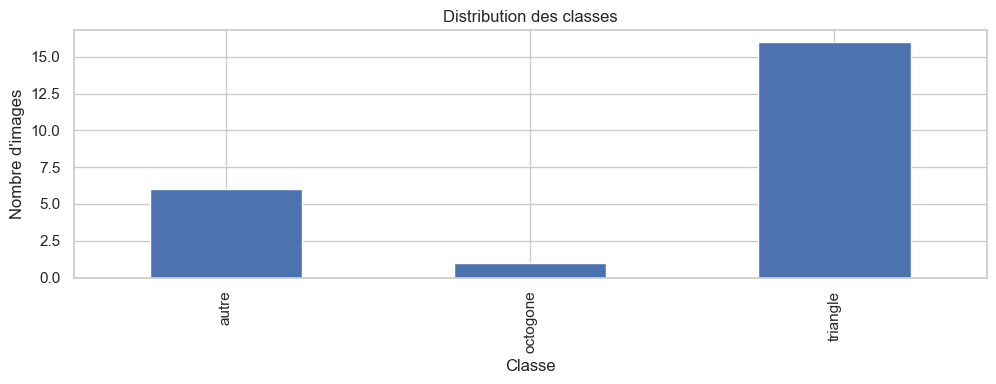

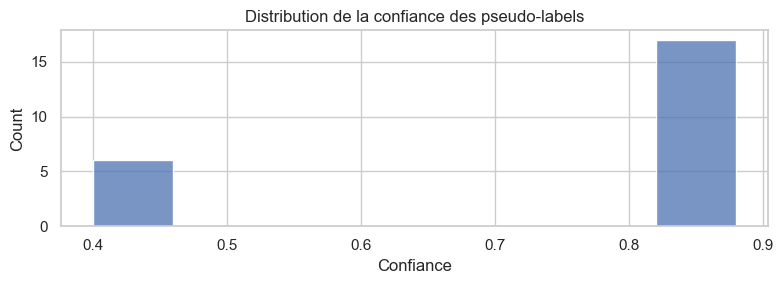

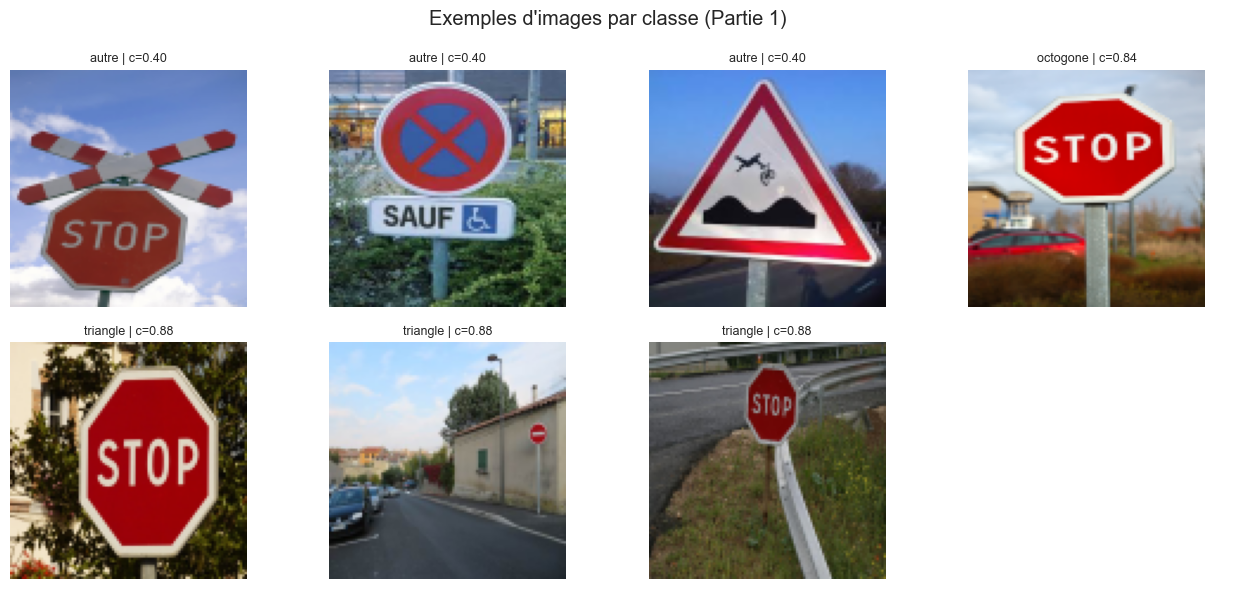

In [34]:
def read_rgb(path, size=None):
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    if size is not None:
        img = cv2.resize(img, size, interpolation=cv2.INTER_AREA)
    return img

label_counts = df['label_raw'].value_counts().sort_index()
plt.figure(figsize=(10, 4))
label_counts.plot(kind='bar')
plt.title('Distribution des classes')
plt.xlabel('Classe')
plt.ylabel("Nombre d'images")
plt.tight_layout()
plt.show()

if 'confidence' in df.columns:
    plt.figure(figsize=(8, 3))
    sns.histplot(df['confidence'], bins=8, kde=False)
    plt.title('Distribution de la confiance des pseudo-labels')
    plt.xlabel('Confiance')
    plt.tight_layout()
    plt.show()

# Montrer plusieurs exemples par classe sans utiliser groupby.apply (robuste pandas)
samples_per_class = 3
sample = (
    df.sample(frac=1.0, random_state=SEED)
      .groupby('label_raw', sort=True, as_index=False)
      .head(samples_per_class)
      .reset_index(drop=True)
      .sort_values('label_raw')
)

n = len(sample)
cols = 4
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(13, 3 * rows))
axes = np.array(axes).reshape(-1)
for ax in axes:
    ax.axis('off')

for i, (_, r) in enumerate(sample.iterrows()):
    axes[i].imshow(read_rgb(r['path'], size=(100, 100)))
    title = str(r['label_raw'])
    if 'confidence' in sample.columns:
        title += f" | c={float(r['confidence']):.2f}"
    axes[i].set_title(title, fontsize=9)
    axes[i].axis('off')

plt.suptitle("Exemples d'images par classe (Partie 1)")
plt.tight_layout()
plt.show()

In [35]:
# Pretraitement commun
encoder = LabelEncoder()
df['label_idx'] = encoder.fit_transform(df['label_raw'])
class_names = list(encoder.classes_)
num_classes = len(class_names)

stratify_col = df['label_idx'] if df['label_idx'].value_counts().min() >= 2 else None
train_df, test_df = train_test_split(df, test_size=0.25, random_state=SEED, stratify=stratify_col)
stratify_train = train_df['label_idx'] if train_df['label_idx'].value_counts().min() >= 2 else None
train_df, val_df = train_test_split(train_df, test_size=0.25, random_state=SEED, stratify=stratify_train)

print(f'Train={len(train_df)} | Val={len(val_df)} | Test={len(test_df)} | Classes={num_classes}')
print('Classes:', class_names)

Train=12 | Val=5 | Test=6 | Classes=3
Classes: ['autre', 'octogone', 'triangle']


## Partie 2 - Approche classique (descripteurs + SVM)

Objectif : extraire des descripteurs HOG + couleur, puis entraîner un SVM.

In [36]:
def extract_features_classic(path, size=(64, 64)):
    bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    bgr = cv2.resize(bgr, size, interpolation=cv2.INTER_AREA)
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)

    hog_vec = hog(gray, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2), block_norm='L2-Hys')

    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    hist_h = cv2.calcHist([hsv], [0], None, [16], [0, 180]).flatten()
    hist_s = cv2.calcHist([hsv], [1], None, [16], [0, 256]).flatten()
    hist_v = cv2.calcHist([hsv], [2], None, [16], [0, 256]).flatten()
    color_vec = np.concatenate([hist_h, hist_s, hist_v])
    color_vec = color_vec / (np.linalg.norm(color_vec) + 1e-8)

    return np.concatenate([hog_vec, color_vec]).astype(np.float32)

def build_xy(dataframe):
    X, y = [], []
    for _, row in dataframe.iterrows():
        X.append(extract_features_classic(row['path'], size=IMG_SIZE))
        y.append(int(row['label_idx']))
    return np.array(X), np.array(y)

X_train, y_train = build_xy(train_df)
X_val, y_val = build_xy(val_df)
X_test, y_test = build_xy(test_df)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

t0 = time.time()
svm = LinearSVC(C=1.0, class_weight='balanced', max_iter=7000)
svm.fit(X_train_s, y_train)
time_classic = time.time() - t0

pred_classic = svm.predict(X_test_s)
acc_classic = accuracy_score(y_test, pred_classic)
pr_classic, rc_classic, f1_classic, _ = precision_recall_fscore_support(y_test, pred_classic, average='weighted', zero_division=0)

print('Approche classique - resultat test')
print(f'accuracy={acc_classic:.4f} | precision={pr_classic:.4f} | recall={rc_classic:.4f} | f1={f1_classic:.4f}')
print(f'temps entrainement={time_classic:.2f}s')
print(classification_report(y_test, pred_classic, target_names=[str(c) for c in class_names], zero_division=0))

Approche classique - resultat test
accuracy=0.5000 | precision=0.6333 | recall=0.5000 | f1=0.4405
temps entrainement=0.00s
              precision    recall  f1-score   support

       autre       1.00      0.33      0.50         3
    octogone       0.00      0.00      0.00         1
    triangle       0.40      1.00      0.57         2

    accuracy                           0.50         6
   macro avg       0.47      0.44      0.36         6
weighted avg       0.63      0.50      0.44         6



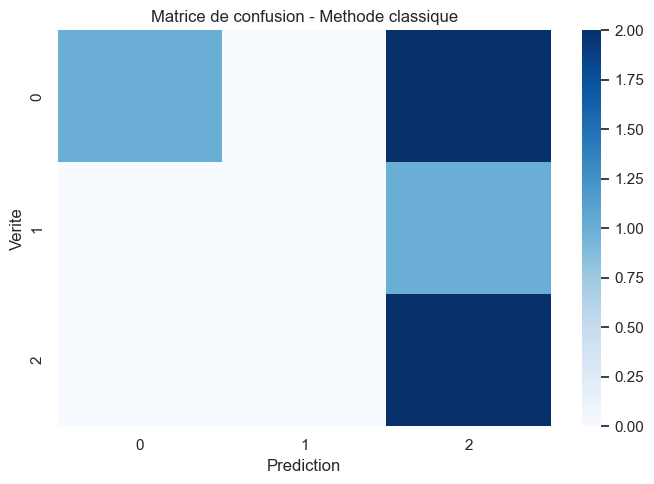

In [37]:
cm_classic = confusion_matrix(y_test, pred_classic)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_classic, annot=False, cmap='Blues')
plt.title('Matrice de confusion - Methode classique')
plt.xlabel('Prediction')
plt.ylabel('Verite')
plt.tight_layout()
plt.show()

## Partie 3 - Méthode supervisée (CNN maison)

Objectif : entraîner une architecture CNN simple, analyser les performances et faire des ablations.

In [38]:
def load_tensor_xy(dataframe, size=(64, 64)):
    X, y = [], []
    for _, row in dataframe.iterrows():
        bgr = cv2.imread(str(row['path']), cv2.IMREAD_COLOR)
        bgr = cv2.resize(bgr, size, interpolation=cv2.INTER_AREA)
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        X.append(rgb.astype(np.float32) / 255.0)
        y.append(int(row['label_idx']))
    return np.array(X), np.array(y)

Xtr, ytr = load_tensor_xy(train_df, size=IMG_SIZE)
Xva, yva = load_tensor_xy(val_df, size=IMG_SIZE)
Xte, yte = load_tensor_xy(test_df, size=IMG_SIZE)

def make_cnn(use_aug=True, dropout=0.3, base=24):
    inp = keras.Input(shape=(IMG_SIZE[1], IMG_SIZE[0], 3))
    x = inp
    if use_aug:
        aug = keras.Sequential([
            keras.layers.RandomFlip('horizontal'),
            keras.layers.RandomRotation(0.08),
            keras.layers.RandomZoom(0.1),
        ])
        x = aug(x)

    x = keras.layers.Conv2D(base, 3, padding='same', activation='relu')(x)
    x = keras.layers.MaxPooling2D()(x)
    x = keras.layers.Conv2D(base * 2, 3, padding='same', activation='relu')(x)
    x = keras.layers.MaxPooling2D()(x)
    x = keras.layers.Conv2D(base * 4, 3, padding='same', activation='relu')(x)
    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.Dropout(dropout)(x)
    out = keras.layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inp, out)
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

cw = compute_class_weight(class_weight='balanced', classes=np.unique(ytr), y=ytr)
class_weight = {int(c): float(w) for c, w in zip(np.unique(ytr), cw)}

cnn = make_cnn(use_aug=True, dropout=0.3, base=24)
t0 = time.time()
hist_cnn = cnn.fit(
    Xtr, ytr,
    validation_data=(Xva, yva),
    epochs=EPOCHS_CNN,
    batch_size=BATCH_SIZE,
    class_weight=class_weight,
    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)],
    verbose=1
)
time_cnn = time.time() - t0

pred_cnn = np.argmax(cnn.predict(Xte, verbose=0), axis=1)
acc_cnn = accuracy_score(yte, pred_cnn)
pr_cnn, rc_cnn, f1_cnn, _ = precision_recall_fscore_support(yte, pred_cnn, average='weighted', zero_division=0)

print('CNN maison - resultat test')
print(f'accuracy={acc_cnn:.4f} | precision={pr_cnn:.4f} | recall={rc_cnn:.4f} | f1={f1_cnn:.4f}')
print(f'temps entrainement={time_cnn:.2f}s')

Epoch 1/4
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.3333 - loss: 1.1374 - val_accuracy: 0.8000 - val_loss: 0.9901
Epoch 2/4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.5000 - loss: 0.9813 - val_accuracy: 0.2000 - val_loss: 0.9214
Epoch 3/4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.1667 - loss: 0.9333 - val_accuracy: 0.2000 - val_loss: 0.8698
Epoch 4/4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.0833 - loss: 0.8653 - val_accuracy: 0.2000 - val_loss: 0.8318
CNN maison - resultat test
accuracy=0.5000 | precision=0.2500 | recall=0.5000 | f1=0.3333
temps entrainement=1.51s


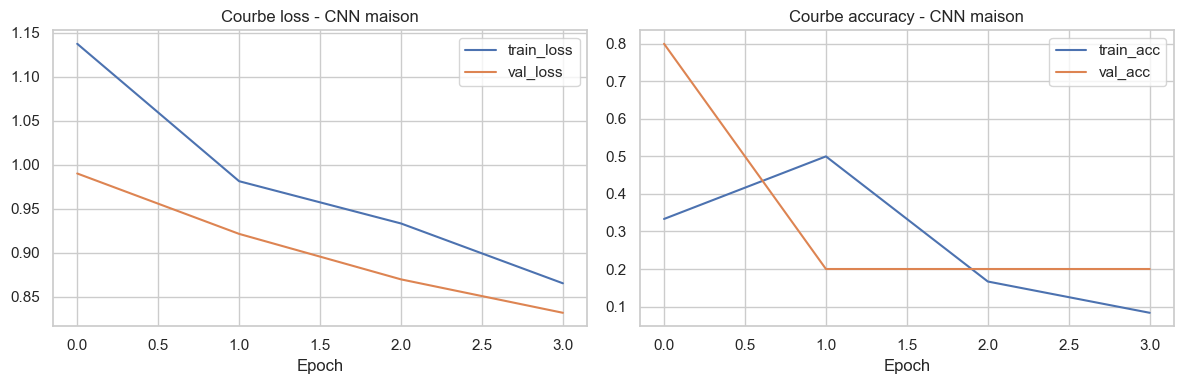

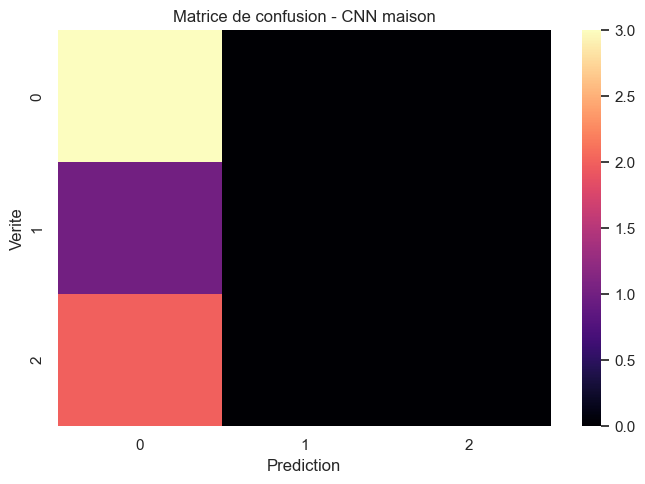

In [39]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(hist_cnn.history['loss'], label='train_loss')
plt.plot(hist_cnn.history['val_loss'], label='val_loss')
plt.title('Courbe loss - CNN maison')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist_cnn.history['accuracy'], label='train_acc')
plt.plot(hist_cnn.history['val_accuracy'], label='val_acc')
plt.title('Courbe accuracy - CNN maison')
plt.xlabel('Epoch')
plt.legend()
plt.tight_layout()
plt.show()

cm_cnn = confusion_matrix(yte, pred_cnn)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_cnn, annot=False, cmap='magma')
plt.title('Matrice de confusion - CNN maison')
plt.xlabel('Prediction')
plt.ylabel('Verite')
plt.tight_layout()
plt.show()

In [40]:
# Ablations (3 experiences minimum)
def run_ablation(name, use_aug, use_class_weight, dropout, base):
    model = make_cnn(use_aug=use_aug, dropout=dropout, base=base)
    t0 = time.time()
    model.fit(
        Xtr, ytr,
        validation_data=(Xva, yva),
        epochs=max(2, EPOCHS_CNN - 1),
        batch_size=BATCH_SIZE,
        class_weight=(class_weight if use_class_weight else None),
        verbose=0
    )
    elapsed = time.time() - t0
    pred = np.argmax(model.predict(Xva, verbose=0), axis=1)
    acc = accuracy_score(yva, pred)
    pr, rc, f1, _ = precision_recall_fscore_support(yva, pred, average='weighted', zero_division=0)
    return {
        'experience': name,
        'augmentation': use_aug,
        'class_weight': use_class_weight,
        'dropout': dropout,
        'base_filters': base,
        'val_accuracy': acc,
        'val_precision': pr,
        'val_recall': rc,
        'val_f1': f1,
        'train_time_s': elapsed
    }

ablation_cfgs = [
    ('A0_baseline', True, True, 0.3, 24),
    ('A1_sans_augmentation', False, True, 0.3, 24),
    ('A2_sans_class_weight', True, False, 0.3, 24),
    ('A3_plus_petit', True, True, 0.2, 16),
]

ablation_results = [run_ablation(*cfg) for cfg in ablation_cfgs]
ablation_df = pd.DataFrame(ablation_results).sort_values('val_f1', ascending=False)
ablation_df

,experience,augmentation,class_weight,dropout,base_filters,val_accuracy,val_precision,val_recall,val_f1,train_time_s
0,A0_baseline,True,True,0.3,24,0.8,0.64,0.8,0.711111,1.261485
2,A2_sans_class_weight,True,False,0.3,24,0.8,0.64,0.8,0.711111,1.396241
1,A1_sans_augmentation,False,True,0.3,24,0.2,0.04,0.2,0.066667,1.019384
3,A3_plus_petit,True,True,0.2,16,0.2,0.04,0.2,0.066667,1.378199


## Partie 4 - Modèle pré-entraîné (Transfer Learning)

Objectif : comparer un backbone MobileNetV2 au CNN maison.

In [41]:
IMG_TL = (96, 96)
Xtr_tl, ytr_tl = load_tensor_xy(train_df, size=IMG_TL)
Xva_tl, yva_tl = load_tensor_xy(val_df, size=IMG_TL)
Xte_tl, yte_tl = load_tensor_xy(test_df, size=IMG_TL)

def build_tl_model(n_classes):
    inp = keras.Input(shape=(IMG_TL[1], IMG_TL[0], 3))
    x = keras.applications.mobilenet_v2.preprocess_input(inp * 255.0)
    try:
        base = keras.applications.MobileNetV2(include_top=False, weights='imagenet', input_shape=(IMG_TL[1], IMG_TL[0], 3))
        print('MobileNetV2 charge avec poids ImageNet.')
    except Exception as e:
        print('Chargement ImageNet impossible, fallback weights=None ->', e)
        base = keras.applications.MobileNetV2(include_top=False, weights=None, input_shape=(IMG_TL[1], IMG_TL[0], 3))

    base.trainable = False
    x = base(x, training=False)
    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.Dropout(0.2)(x)
    out = keras.layers.Dense(n_classes, activation='softmax')(x)

    model = keras.Model(inp, out)
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model, base

tl_model, tl_base = build_tl_model(num_classes)
t0 = time.time()
hist_tl_1 = tl_model.fit(Xtr_tl, ytr_tl, validation_data=(Xva_tl, yva_tl), epochs=EPOCHS_TL_FREEZE, batch_size=BATCH_SIZE, verbose=1)

tl_base.trainable = True
for layer in tl_base.layers[:-30]:
    layer.trainable = False
tl_model.compile(optimizer=keras.optimizers.Adam(1e-5), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
hist_tl_2 = tl_model.fit(Xtr_tl, ytr_tl, validation_data=(Xva_tl, yva_tl), epochs=EPOCHS_TL_FINETUNE, batch_size=BATCH_SIZE, verbose=1)
time_tl = time.time() - t0

pred_tl = np.argmax(tl_model.predict(Xte_tl, verbose=0), axis=1)
acc_tl = accuracy_score(yte_tl, pred_tl)
pr_tl, rc_tl, f1_tl, _ = precision_recall_fscore_support(yte_tl, pred_tl, average='weighted', zero_division=0)

print('Transfer learning - resultat test')
print(f'accuracy={acc_tl:.4f} | precision={pr_tl:.4f} | recall={rc_tl:.4f} | f1={f1_tl:.4f}')
print(f'temps entrainement={time_tl:.2f}s')

MobileNetV2 charge avec poids ImageNet.
Epoch 1/2
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.1667 - loss: 1.6792 - val_accuracy: 0.6000 - val_loss: 0.8712
Epoch 2/2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.3333 - loss: 1.2018 - val_accuracy: 0.6000 - val_loss: 0.5576
Epoch 1/2
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.8333 - loss: 0.4092 - val_accuracy: 0.6000 - val_loss: 0.5477
Epoch 2/2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.8333 - loss: 0.3986 - val_accuracy: 0.6000 - val_loss: 0.5448
Transfer learning - resultat test
accuracy=0.5000 | precision=0.6333 | recall=0.5000 | f1=0.4405
temps entrainement=9.30s


,modele,accuracy,precision,recall,f1,train_time_s
0,Classique_SVM,0.5,0.633333,0.5,0.440476,0.001449
2,MobileNetV2_transfer,0.5,0.633333,0.5,0.440476,9.302989
1,CNN_maison,0.5,0.250000,0.5,0.333333,1.512996


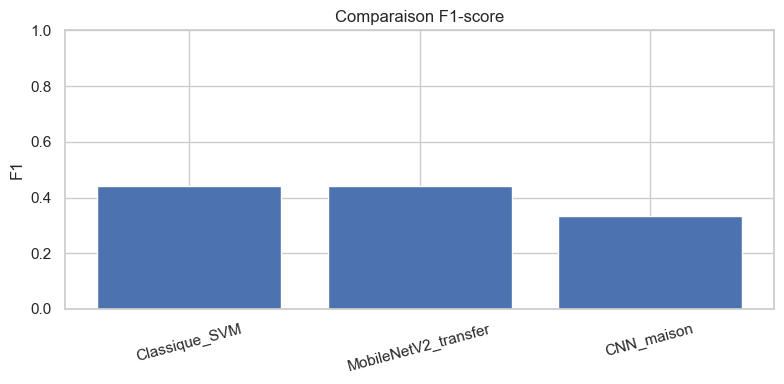

In [42]:
results = pd.DataFrame([
    {'modele': 'Classique_SVM', 'accuracy': acc_classic, 'precision': pr_classic, 'recall': rc_classic, 'f1': f1_classic, 'train_time_s': time_classic},
    {'modele': 'CNN_maison', 'accuracy': acc_cnn, 'precision': pr_cnn, 'recall': rc_cnn, 'f1': f1_cnn, 'train_time_s': time_cnn},
    {'modele': 'MobileNetV2_transfer', 'accuracy': acc_tl, 'precision': pr_tl, 'recall': rc_tl, 'f1': f1_tl, 'train_time_s': time_tl},
]).sort_values('f1', ascending=False)

display(results)

plt.figure(figsize=(8, 4))
plt.bar(results['modele'], results['f1'])
plt.title('Comparaison F1-score')
plt.ylabel('F1')
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

Image exemple: C:\Users\madaggag\Documents\Python\Project\Cours\Traitement_Image\im\panneaux\im01.png


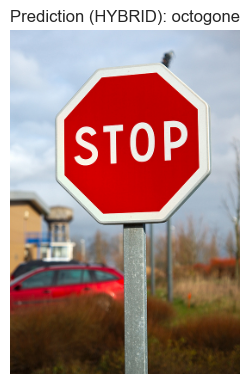

Modele utilise : hybrid
Classe predite : octogone
Top-3 classes :
  - triangle: 0.9739
  - autre: -0.9739
Regle forme/couleur: {'pred_label': 'octogone', 'confidence': 0.84}


In [46]:
def _choose_model_for_inference(model_choice='auto'):
    choice = model_choice.lower()
    if choice == 'auto':
        # Sur ce mini dataset local, le mode hybride est plus robuste
        return 'hybrid'

    if choice not in {'svm', 'cnn', 'tl', 'hybrid', 'rule'}:
        raise ValueError("model_choice doit etre 'auto', 'svm', 'cnn', 'tl', 'hybrid' ou 'rule'.")
    return choice

def _predict_rule_only(img_bgr):
    if 'shape_pseudo_label' not in globals():
        raise RuntimeError("shape_pseudo_label n'est pas disponible.")
    lbl, conf = shape_pseudo_label(img_bgr)
    return {'pred_label': lbl, 'confidence': float(conf)}

def _predict_svm(img_path):
    if 'extract_features_classic' not in globals():
        raise RuntimeError('Fonction extract_features_classic absente. Relance la partie classique.')
    feat = extract_features_classic(str(img_path), size=IMG_SIZE).reshape(1, -1)
    feat_s = scaler.transform(feat)
    pred_idx = int(svm.predict(feat_s)[0])
    pred_label = class_names[pred_idx]

    top3 = [(pred_label, 1.0)]
    if hasattr(svm, 'decision_function'):
        scores = svm.decision_function(feat_s)
        classes_local = list(getattr(svm, 'classes_', []))

        if isinstance(scores, np.ndarray) and scores.ndim == 2:
            s = scores[0]
            order = np.argsort(s)[::-1][: min(3, len(s))]
            top3 = [(class_names[int(classes_local[i])], float(s[i])) for i in order]
        elif isinstance(scores, np.ndarray) and scores.ndim == 1:
            margin = float(scores[0])
            if len(classes_local) == 2:
                c0, c1 = int(classes_local[0]), int(classes_local[1])
                top3 = [
                    (class_names[c1], margin),
                    (class_names[c0], -margin),
                ] if margin >= 0 else [
                    (class_names[c0], -margin),
                    (class_names[c1], margin),
                ]
    return {'pred_label': pred_label, 'top3': top3}

def _predict_nn(img_bgr, model_kind='cnn'):
    target_size = IMG_TL if model_kind == 'tl' else IMG_SIZE
    model = tl_model if model_kind == 'tl' else cnn

    img_resized = cv2.resize(img_bgr, target_size, interpolation=cv2.INTER_AREA)
    img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    batch = np.expand_dims(img_rgb, axis=0)
    probs = model.predict(batch, verbose=0)[0]
    pred_idx = int(np.argmax(probs))
    top_idx = np.argsort(probs)[::-1][: min(3, len(probs))]
    top3 = [(class_names[int(i)], float(probs[int(i)])) for i in top_idx]
    return {'pred_label': class_names[pred_idx], 'top3': top3}

def predict_sign_from_path(image_path, model_choice='auto', show_image=True):
    img_path = Path(image_path)
    if not img_path.exists():
        raise FileNotFoundError(f'Image introuvable: {img_path}')

    chosen = _choose_model_for_inference(model_choice)
    img_bgr = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
    if img_bgr is None:
        raise RuntimeError('Lecture image impossible (format non supporte ou fichier corrompu).')

    if chosen == 'rule':
        rule = _predict_rule_only(img_bgr)
        pred_label = rule['pred_label']
        top3 = [(pred_label, rule['confidence'])]
        model_used = 'rule'
    elif chosen == 'svm':
        out = _predict_svm(img_path)
        pred_label, top3 = out['pred_label'], out['top3']
        model_used = 'svm'
    elif chosen in {'cnn', 'tl'}:
        out = _predict_nn(img_bgr, model_kind=chosen)
        pred_label, top3 = out['pred_label'], out['top3']
        model_used = chosen
    else:
        # hybrid = regles + modele appris
        rule = _predict_rule_only(img_bgr)
        out_model = _predict_svm(img_path) if ('svm' in globals() and 'scaler' in globals()) else _predict_nn(img_bgr, model_kind='cnn')
        pred_model = out_model['pred_label']

        # Priorite aux regles si elles detectent clairement une forme de panneau
        if rule['pred_label'] != 'autre' and rule['confidence'] >= 0.75:
            pred_label = rule['pred_label']
        else:
            pred_label = pred_model

        top3 = out_model['top3']
        model_used = 'hybrid'

    if show_image:
        show_img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(4, 4))
        plt.imshow(show_img)
        plt.title(f"Prediction ({model_used.upper()}): {pred_label}")
        plt.axis('off')
        plt.tight_layout()
        plt.show()

    print('Modele utilise :', model_used)
    print('Classe predite :', pred_label)
    print('Top-3 classes :')
    for name, score in top3:
        print(f'  - {name}: {score:.4f}')

    if chosen == 'hybrid':
        print('Regle forme/couleur:', _predict_rule_only(img_bgr))

    return {'model': model_used, 'pred_label': pred_label, 'top3': top3}

# Exemple d'utilisation
SAMPLE_SIGN_PATH = str((PROJECT_ROOT / 'im' / 'panneaux' / 'im01.png'))
print('Image exemple:', SAMPLE_SIGN_PATH)
_ = predict_sign_from_path(SAMPLE_SIGN_PATH, model_choice='auto', show_image=True)

## Inference - Donner une image, obtenir le panneau

Objectif: si tu fournis une image de panneau, le notebook renvoie la classe predite.

Utilisation simple:
- mets le chemin dans `SAMPLE_SIGN_PATH`
- execute la cellule de prediction

## Conclusion

- Le SVM avec descripteurs manuels donne une baseline rapide.
- Le CNN maison apprend des caractéristiques plus robustes.
- Le transfer learning est généralement le meilleur compromis performance/temps (selon données disponibles).

Limites : taille/qualité du dataset local, pseudo-labels si GTSRB absent.
Améliorations : plus de données annotées, augmentation avancée, réglage d'hyperparamètres.

In [43]:
print('=== Resume final ===')
best = results.iloc[0]
print('Meilleur modele :', best['modele'])
print(f"Meilleure accuracy : {best['accuracy']:.4f}")
print(f"Meilleure precision : {best['precision']:.4f}")
print(f"Meilleur recall : {best['recall']:.4f}")
print(f"Meilleur F1-score : {best['f1']:.4f}")
print(f"Temps entrainement : {best['train_time_s']:.2f}s")

=== Resume final ===
Meilleur modele : Classique_SVM
Meilleure accuracy : 0.5000
Meilleure precision : 0.6333
Meilleur recall : 0.5000
Meilleur F1-score : 0.4405
Temps entrainement : 0.00s
